# Logistic Regression Model for Particle Classification

## 1. Import Packages

In [9]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt

## 2. Load and Inspect the Dataset

In [10]:
df = pd.read_parquet("../../data/processed/particle_labeled.parquet")

print(df.shape)
print(df.columns.tolist())
df.head()

(2801667, 95)
['stub_id', 'particle_id', 'relevance_class', 'ac', 'ag', 'al', 'ar', 'as', 'at', 'au', 'b', 'ba', 'bi', 'br', 'ca', 'cd', 'ce', 'cl', 'co', 'cr', 'cs', 'cu', 'dy', 'er', 'eu', 'f', 'fe', 'fr', 'ga', 'gd', 'ge', 'hf', 'hg', 'ho', 'i', 'in', 'ir', 'k', 'kr', 'la', 'lu', 'mg', 'mn', 'mo', 'n', 'na', 'nb', 'nd', 'ne', 'ni', 'np', 'o', 'os', 'p', 'pa', 'pb', 'pd', 'pm', 'po', 'pr', 'pt', 'pu', 'ra', 'rb', 're', 'rh', 'rn', 'ru', 's', 'sb', 'sc', 'se', 'si', 'sm', 'sn', 'sr', 'ta', 'tb', 'tc', 'te', 'th', 'ti', 'tl', 'tm', 'u', 'v', 'w', 'xe', 'y', 'yb', 'zn', 'zr', 'merged_relevance_class', 'final_class', 'label']


,stub_id,particle_id,relevance_class,ac,ag,al,ar,as,at,au,...,v,w,xe,y,yb,zn,zr,merged_relevance_class,final_class,label
0,22,1454,PbSb,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,PbSb,PbSb,GSR
1,22,1274,PbSbBa,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,PbSbBa,PbBaSb,GSR
2,22,275,PbSbBa,0.0,0.0,0.751013,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,PbSbBa,PbBaSb,GSR
3,22,714,PbSbBa,0.0,0.0,0.824510,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,PbSbBa,PbBaSb,GSR
4,22,2887,PbSb,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,PbSb,PbSb,GSR


## 3. Identify and Clean the Target Variable

In [11]:
for col in df.columns:
    if df[col].nunique() < 10:
        print(col, df[col].unique())

label <ArrowStringArray>
['GSR', 'Ambiguous', 'Non_GSR']
Length: 3, dtype: str


In [12]:
target_col = "label"
df = df.dropna(subset=[target_col]).copy()

In [13]:
target_col = "label"

# normalize label formatting to fix string mismatches
df[target_col] = (
    df[target_col]
    .astype(str)
    .str.strip()
    .str.lower()
)

# fix known label mismatch bug
df[target_col] = df[target_col].replace({
    "non-gsr": "non_gsr",
    "non gsr": "non_gsr",
    "gsr": "gsr",
    "ambiguous": "ambiguous"
})

print(df[target_col].value_counts(dropna=False))

label
non_gsr      1216039
gsr          1078946
ambiguous     506682
Name: count, dtype: int64


In [14]:
# keep only binary classes for logistic regression
df = df[df[target_col].isin(["non_gsr", "gsr"])].copy()

print(df[target_col].value_counts(dropna=False))

label
non_gsr    1216039
gsr        1078946
Name: count, dtype: int64


In [15]:
X = df.drop(columns=[target_col])
X = X.select_dtypes(include=[np.number])

y = df[target_col].map({
    "non_gsr": 0,
    "gsr": 1
})

print(y.value_counts(dropna=False))
print("Unique y values:", y.unique())

label
0    1216039
1    1078946
Name: count, dtype: int64
Unique y values: [1 0]


In [16]:
if y.isna().any():
    raise ValueError("y contains NaN values after mapping. Check label values above.")

if y.nunique() < 2:
    raise ValueError(
        f"y contains fewer than 2 classes after cleaning. Found classes: {sorted(y.dropna().unique())}"
    )

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("y_train distribution:")
print(y_train.value_counts())

print("\ny_test distribution:")
print(y_test.value_counts())

y_train distribution:
label
0    972831
1    863157
Name: count, dtype: int64

y_test distribution:
label
0    243208
1    215789
Name: count, dtype: int64


In [18]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

In [19]:
pipeline.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


In [20]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

[[242513    695]
 [  3673 212116]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    243208
           1       1.00      0.98      0.99    215789

    accuracy                           0.99    458997
   macro avg       0.99      0.99      0.99    458997
weighted avg       0.99      0.99      0.99    458997

ROC AUC: 0.9990274555426456


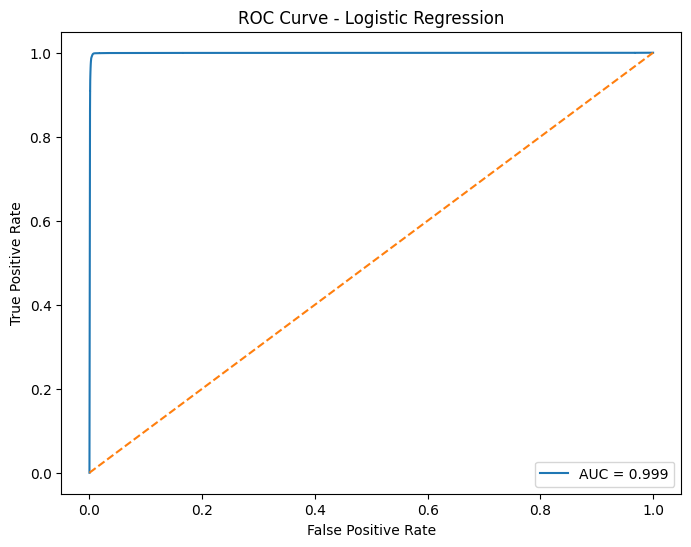

In [21]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

In [22]:
print("Cleaned label distribution:")
print(df[target_col].value_counts(dropna=False))

print("\nMapped y distribution:")
print(y.value_counts(dropna=False))

print("\nUnique y values:")
print(y.unique())

Cleaned label distribution:
label
non_gsr    1216039
gsr        1078946
Name: count, dtype: int64

Mapped y distribution:
label
0    1216039
1    1078946
Name: count, dtype: int64

Unique y values:
[1 0]


In [23]:
df[target_col] = df[target_col].replace({
    "non-gsr": "non_gsr",
    "non gsr": "non_gsr",
})

In [24]:
df = df[df[target_col].isin(["non_gsr", "gsr"])].copy()